# NB04 — Análisis Geoespacial Avanzado
**VíaSegura AI** | Bogotá, Colombia

## Objetivo
Enriquecer el análisis IPI con capas geoespaciales avanzadas:
1. **Hexágonos H3** (resolución 8 ≈ 460m) con IPI agregado → `ipi_hexagonos.geojson`
2. **Polígonos de localidades** con IPI por localidad → `ipi_por_localidad.geojson`
3. **Mapas folium** de choropleth, heatmap y clusters para el dashboard NB06

**Inputs:** `outputs/reports/zonas_criticas_IPI_completo_2016_2019.csv`, `data/processed/accidentes_bogota_2016_2019_limpio.csv`
**Outputs:** GeoJSONs en `outputs/maps/`, HTML en `outputs/maps/`


## 1. Setup y carga de datos

In [1]:
import sys
from pathlib import Path

# ── Resolver raíz del proyecto ───────────────────────────────────────────
_cwd = Path.cwd()
_root = next(
    (c for c in [_cwd, _cwd.parent] if (c / "config.py").exists()),
    _cwd,
)
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from config import PROJECT_ROOT, DATA_RAW, DATA_PROCESSED, REPORTS, MAPS

print(f"PROJECT_ROOT : {PROJECT_ROOT}")
print(f"MAPS         : {MAPS}")


PROJECT_ROOT : C:\Users\jorge\Documents\viasegura_ai
MAPS         : C:\Users\jorge\Documents\viasegura_ai\outputs\maps


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import folium
from folium.plugins import HeatMap, MarkerCluster, FastMarkerCluster
from shapely.geometry import Point, Polygon
import h3
import json

print(f"pandas     {pd.__version__}")
print(f"geopandas  {gpd.__version__}")
print(f"h3         {h3.__version__}")
print(f"folium     {folium.__version__}")


pandas     3.0.2
geopandas  1.1.3
h3         4.4.2
folium     0.20.0


In [3]:
# ── Cargar IPI completo ──────────────────────────────────────────────────
p_ipi = REPORTS / "zonas_criticas_IPI_completo_2016_2019.csv"
df_ipi = pd.read_csv(p_ipi)
print(f"Zonas IPI: {len(df_ipi):,}")
print(f"Columnas: {df_ipi.columns.tolist()[:10]}...")

# ── Cargar accidentes limpios ────────────────────────────────────────────
p_limpio = DATA_PROCESSED / "accidentes_bogota_2016_2019_limpio.csv"
df_acc = pd.read_csv(p_limpio)
print(f"\nAccidentes: {len(df_acc):,}")
print(f"Columnas:   {df_acc.columns.tolist()}")


Zonas IPI: 17,130
Columnas: ['LAT_ZONA', 'LON_ZONA', 'cantidad_siniestros', 'criticidad_total', 'criticidad_promedio', 'localidad_predominante', 'barrio_predominante', 'via_predominante', 'clase_predominante', 'gravedad_predominante']...



Accidentes: 260,831
Columnas:   ['OBJECTID', 'FORMULARIO', 'CODIGO_ACCIDENTE', 'FECHA_OCURRENCIA_ACC', 'HORA_OCURRENCIA_ACC', 'ANO_OCURRENCIA_ACC', 'MES_OCURRENCIA_ACC', 'DIA_OCURRENCIA_ACC', 'DIRECCION', 'GRAVEDAD', 'CLASE_ACC', 'LOCALIDAD', 'MUNICIPIO', 'LATITUD', 'LONGITUD', 'BARRIO', 'MVINOMBRE', 'DISTANCIA_VIA', 'puntaje_gravedad']


In [4]:
# ── GeoDataFrame de zonas IPI ────────────────────────────────────────────
gdf_zonas = gpd.GeoDataFrame(
    df_ipi,
    geometry=gpd.points_from_xy(df_ipi["LON_ZONA"], df_ipi["LAT_ZONA"]),
    crs="EPSG:4326",
)

# Subsets por prioridad
p1 = gdf_zonas[gdf_zonas["prioridad_IPI"].str.contains("Prioridad 1", na=False)].copy()
p2 = gdf_zonas[gdf_zonas["prioridad_IPI"].str.contains("Prioridad 2", na=False)].copy()
p3 = gdf_zonas[gdf_zonas["prioridad_IPI"].str.contains("Prioridad 3", na=False)].copy()

print(f"Total zonas : {len(gdf_zonas):,}")
print(f"Prioridad 1 : {len(p1):,}")
print(f"Prioridad 2 : {len(p2):,}")
print(f"Prioridad 3 : {len(p3):,}")
print(f"Otras       : {len(gdf_zonas) - len(p1) - len(p2) - len(p3):,}")


Total zonas : 17,130
Prioridad 1 : 50
Prioridad 2 : 150
Prioridad 3 : 300
Otras       : 16,630


## 2. Hexágonos H3 (resolución 8 ≈ 460 m de diámetro)

H3 es el sistema de indexación hexagonal de Uber.
Resolución 8 produce hexágonos de ~460m de diámetro, ideal para análisis urbano.


In [5]:
RES_H3 = 8  # ~460m diámetro

# Asignar cada zona a su hexágono H3
gdf_zonas["h3_id"] = gdf_zonas.apply(
    lambda row: h3.latlng_to_cell(row["LAT_ZONA"], row["LON_ZONA"], RES_H3),
    axis=1,
)

print(f"Hexágonos únicos con al menos 1 zona IPI: {gdf_zonas['h3_id'].nunique():,}")
print("\nEjemplo de h3_ids:")
print(gdf_zonas["h3_id"].head())


Hexágonos únicos con al menos 1 zona IPI: 581

Ejemplo de h3_ids:
0    8866e091cdfffff
1    8866e092a9fffff
2    8866e092abfffff
3    8866e09285fffff
4    8866e09325fffff
Name: h3_id, dtype: str


In [6]:
# ── Agregar métricas por hexágono ────────────────────────────────────────
agg_hex = gdf_zonas.groupby("h3_id").agg(
    n_zonas=("IPI", "count"),
    ipi_max=("IPI", "max"),
    ipi_mean=("IPI", "mean"),
    ipi_sum=("IPI", "sum"),
    siniestros_total=("cantidad_siniestros", "sum"),
    criticidad_total=("criticidad_total", "sum"),
    siniestros_muertos=("siniestros_con_muertos", "sum"),
    localidad=("localidad_predominante", lambda x: x.value_counts().idxmax()),
    prioridad_dominante=("prioridad_IPI", lambda x: x.value_counts().idxmax()),
).reset_index()

# IPI del hexágono = max IPI de las zonas contenidas (el peor punto determina la urgencia)
agg_hex = agg_hex.rename(columns={"ipi_max": "IPI_hex"})

print(f"Hexágonos con datos: {len(agg_hex):,}")
print(f"\nTop 5 hexágonos por IPI:")
print(agg_hex.nlargest(5, "IPI_hex")[["h3_id","IPI_hex","siniestros_total","localidad"]])


Hexágonos con datos: 581

Top 5 hexágonos por IPI:
               h3_id    IPI_hex  siniestros_total       localidad
187  8866e091cdfffff  96.275540               342  CIUDAD BOLIVAR
259  8866e092a9fffff  95.778167              1154    LOS MARTIRES
260  8866e092abfffff  95.689434               790      CANDELARIA
251  8866e09285fffff  95.084647              1482        SANTA FE
296  8866e09325fffff  94.994162               172            BOSA


In [7]:
# ── Convertir hexágonos H3 a polígonos Shapely ───────────────────────────
def h3_to_polygon(h3_id: str) -> Polygon:
    """Convierte un h3_id a polígono Shapely (lon, lat)."""
    boundary = h3.cell_to_boundary(h3_id)  # retorna lista de (lat, lon)
    return Polygon([(lon, lat) for lat, lon in boundary])

agg_hex["geometry"] = agg_hex["h3_id"].apply(h3_to_polygon)
gdf_hex = gpd.GeoDataFrame(agg_hex, geometry="geometry", crs="EPSG:4326")

# Calcular centroides para etiquetas
gdf_hex["centroid_lat"] = gdf_hex.geometry.centroid.y
gdf_hex["centroid_lon"] = gdf_hex.geometry.centroid.x

print(f"GeoDataFrame hexágonos: {len(gdf_hex)} filas")
print(gdf_hex.dtypes)


GeoDataFrame hexágonos: 581 filas
h3_id                       str
n_zonas                   int64
IPI_hex                 float64
ipi_mean                float64
ipi_sum                 float64
siniestros_total          int64
criticidad_total          int64
siniestros_muertos        int64
localidad                   str
prioridad_dominante         str
geometry               geometry
centroid_lat            float64
centroid_lon            float64
dtype: object


In [8]:
# ── Clasificar hexágonos por IPI ─────────────────────────────────────────
def clasificar_hex(ipi: float) -> str:
    if ipi >= 90:
        return "Crítico (IPI≥90)"
    elif ipi >= 75:
        return "Alto (75≤IPI<90)"
    elif ipi >= 50:
        return "Medio (50≤IPI<75)"
    else:
        return "Bajo (IPI<50)"

gdf_hex["categoria"] = gdf_hex["IPI_hex"].apply(clasificar_hex)

print("Distribución por categoría:")
print(gdf_hex["categoria"].value_counts())


Distribución por categoría:
categoria
Alto (75≤IPI<90)     270
Crítico (IPI≥90)     153
Medio (50≤IPI<75)     97
Bajo (IPI<50)         61
Name: count, dtype: int64


In [9]:
# ── Exportar GeoJSON de hexágonos ────────────────────────────────────────
p_hex_geojson = MAPS / "ipi_hexagonos_h3.geojson"

# Redondear para reducir tamaño del archivo
gdf_hex_export = gdf_hex.copy()
for col in ["IPI_hex", "ipi_mean", "ipi_sum"]:
    gdf_hex_export[col] = gdf_hex_export[col].round(2)

gdf_hex_export.to_file(p_hex_geojson, driver="GeoJSON")
size_kb = p_hex_geojson.stat().st_size / 1024
print(f"Exportado: {p_hex_geojson.name}  ({size_kb:.1f} KB)")
print(f"Hexágonos: {len(gdf_hex_export):,}")


Exportado: ipi_hexagonos_h3.geojson  (426.0 KB)
Hexágonos: 581


## 3. Polígonos de localidades de Bogotá

Descargamos los límites administrativos de las **20 localidades** de Bogotá
desde OpenStreetMap usando `osmnx`. Luego hacemos un join espacial con las zonas IPI.


In [10]:
import osmnx as ox
import time

p_localidades = MAPS / "bogota_localidades.geojson"

if p_localidades.exists():
    gdf_loc = gpd.read_file(p_localidades)
    print(f"Localidades cargadas desde caché: {len(gdf_loc)} polígonos")
else:
    print("Descargando límites de localidades desde OSM...")
    t0 = time.time()

    # Descargar Bogotá como área administrativa
    gdf_loc = ox.geocode_to_gdf("Bogotá, Colombia")

    # Descargar subdivisiones (localidades = admin_level 9 en Colombia)
    tags = {"admin_level": "9", "boundary": "administrative"}
    try:
        gdf_loc = ox.features_from_place("Bogotá, Colombia", tags=tags)
        gdf_loc = gdf_loc[gdf_loc.geometry.type.isin(["Polygon", "MultiPolygon"])].copy()
        gdf_loc = gdf_loc[["geometry", "name"]].reset_index(drop=True)
        gdf_loc.to_file(p_localidades, driver="GeoJSON")
        print(f"  Descargadas {len(gdf_loc)} localidades en {time.time()-t0:.1f}s")
    except Exception as e:
        print(f"  Advertencia OSM: {e}")
        print("  Generando polígonos aproximados por localidad desde datos IPI...")

        # Fallback: crear polígonos convex hull por localidad desde las zonas IPI
        gdf_loc_fallback = (
            gdf_zonas.groupby("localidad_predominante")
            .apply(lambda g: g.unary_union.convex_hull)
            .reset_index()
        )
        gdf_loc_fallback.columns = ["name", "geometry"]
        gdf_loc = gpd.GeoDataFrame(gdf_loc_fallback, geometry="geometry", crs="EPSG:4326")
        gdf_loc = gdf_loc[~gdf_loc["name"].isna() & (gdf_loc["name"] != "")].copy()
        gdf_loc.to_file(p_localidades, driver="GeoJSON")
        print(f"  Generadas {len(gdf_loc)} localidades (convex hull desde zonas IPI)")

print(f"\nLocalidades disponibles:")
print(gdf_loc[["name"]].to_string() if "name" in gdf_loc.columns else gdf_loc.head())


Localidades cargadas desde caché: 274 polígonos

Localidades disponibles:
                                    name
0                               Colombia
1                           Cundinamarca
2                    Localidad Chapinero
3    Bogotá Distrito Capital - Municipio
4                                  Funza
5                               Mosquera
6                                 Soacha
7               Localidad Barrios Unidos
8                     Localidad Engativá
9                         Localidad Suba
10                     Localidad Usaquén
11                    Localidad Fontibón
12                Localidad Los Mártires
13                 Localidad Teusaquillo
14              Localidad Antonio Nariño
15               Localidad Puente Aranda
16                  Localidad Tunjuelito
17               Localidad La Candelaria
18                               Cerezos
19                              Quirigua
20                               Sidauto
21                      

In [11]:
# ── Asegurar CRS compatible ──────────────────────────────────────────────
gdf_loc = gdf_loc.to_crs("EPSG:4326")

# Normalizar nombre de columna
if "name" in gdf_loc.columns:
    gdf_loc = gdf_loc.rename(columns={"name": "localidad"})
elif "NOMBRE" in gdf_loc.columns:
    gdf_loc = gdf_loc.rename(columns={"NOMBRE": "localidad"})

# Limpiar geometrías inválidas
gdf_loc = gdf_loc[gdf_loc.geometry.is_valid & ~gdf_loc.geometry.is_empty].copy()
gdf_loc = gdf_loc.reset_index(drop=True)

print(f"Localidades limpias: {len(gdf_loc)}")
print(gdf_loc[["localidad"]].head(10) if "localidad" in gdf_loc.columns else gdf_loc.head())


Localidades limpias: 274
                             localidad
0                             Colombia
1                         Cundinamarca
2                  Localidad Chapinero
3  Bogotá Distrito Capital - Municipio
4                                Funza
5                             Mosquera
6                               Soacha
7             Localidad Barrios Unidos
8                   Localidad Engativá
9                       Localidad Suba


## 4. Join espacial: zonas IPI → localidades

In [12]:
# ── Spatial join: cada zona IPI → localidad que la contiene ─────────────
gdf_join = gpd.sjoin(
    gdf_zonas[["geometry", "IPI", "rank_IPI", "cantidad_siniestros",
               "siniestros_con_muertos", "criticidad_total",
               "score_volumen", "score_fatalidad", "prioridad_IPI",
               "localidad_predominante"]],
    gdf_loc[["geometry", "localidad"]],
    how="left",
    predicate="within",
)

# Zonas sin localidad asignada (fuera de los polígonos descargados)
sin_loc = gdf_join["localidad"].isna().sum()
if sin_loc > 0:
    print(f"Zonas sin localidad asignada por sjoin: {sin_loc} → usando localidad_predominante como fallback")
    gdf_join["localidad"] = gdf_join["localidad"].fillna(gdf_join["localidad_predominante"])

print(f"Zonas con localidad asignada: {gdf_join['localidad'].notna().sum():,}")
print(f"Distribución (top 10):")
print(gdf_join["localidad"].value_counts().head(10))


Zonas con localidad asignada: 135,334
Distribución (top 10):


localidad
Colombia                               17130
Bogotá Distrito Capital - Municipio    17109
Bogotá, Distrito Capital               17109
UPZs de Bogotá                         16970
Bogotá                                 16910
Localidad Suba                          2122
Localidad Kennedy                       1856
UPZs Localidad Kennedy                  1856
Localidad Engativá                      1711
UPZs Localidad Engativá                 1711
Name: count, dtype: int64


In [13]:
# ── Agregar IPI por localidad ────────────────────────────────────────────
ipi_por_loc = gdf_join.groupby("localidad").agg(
    n_zonas=("IPI", "count"),
    ipi_max=("IPI", "max"),
    ipi_medio=("IPI", "mean"),
    ipi_p75=("IPI", lambda x: x.quantile(0.75)),
    siniestros_total=("cantidad_siniestros", "sum"),
    siniestros_muertos=("siniestros_con_muertos", "sum"),
    criticidad_total=("criticidad_total", "sum"),
    zonas_p1=("prioridad_IPI", lambda x: (x.str.contains("Prioridad 1", na=False)).sum()),
    zonas_p2=("prioridad_IPI", lambda x: (x.str.contains("Prioridad 2", na=False)).sum()),
).reset_index()

# IPI representativo: usamos el percentil 75 de las zonas (más robusto que el max)
ipi_por_loc = ipi_por_loc.rename(columns={"ipi_p75": "IPI_localidad"})
ipi_por_loc["rank_localidad"] = ipi_por_loc["IPI_localidad"].rank(
    ascending=False, method="min"
).astype(int)
ipi_por_loc = ipi_por_loc.sort_values("IPI_localidad", ascending=False).reset_index(drop=True)

print("IPI por localidad (top 10):")
print(ipi_por_loc[["localidad","IPI_localidad","siniestros_total","zonas_p1","siniestros_muertos"]].head(10).to_string())


IPI por localidad (top 10):
            localidad  IPI_localidad  siniestros_total  zonas_p1  siniestros_muertos
0          El Remanso      80.970228               222         0                   6
1               Olaya      78.913894               556         0                  20
2            Mandalay      77.867776               894         0                  12
3         Santa Lucía      77.356976               548         0                   8
4      La Paz Central      77.061004                80         0                   0
5        Murillo Toro      77.059545               138         0                   8
6  UPZ Las Margaritas      76.942207               564         0                   8
7      UPZ Las Nieves      76.884997              3664         7                  66
8              Samper      76.744600               324         0                   2
9             Quiroga      76.142148               746         1                  18


In [14]:
# ── Merge con GeoDataFrame de localidades ───────────────────────────────
gdf_loc_ipi = gdf_loc.merge(ipi_por_loc, on="localidad", how="left")
gdf_loc_ipi["IPI_localidad"] = gdf_loc_ipi["IPI_localidad"].fillna(0)
gdf_loc_ipi["siniestros_total"] = gdf_loc_ipi["siniestros_total"].fillna(0)

print(f"Localidades con IPI calculado: {gdf_loc_ipi['IPI_localidad'].gt(0).sum()}/{len(gdf_loc_ipi)}")

# Exportar GeoJSON de localidades
p_loc_geojson = MAPS / "ipi_por_localidad.geojson"
gdf_loc_ipi_export = gdf_loc_ipi.copy()
for col in ["IPI_localidad", "ipi_medio", "ipi_max"]:
    if col in gdf_loc_ipi_export.columns:
        gdf_loc_ipi_export[col] = gdf_loc_ipi_export[col].round(2)
gdf_loc_ipi_export.to_file(p_loc_geojson, driver="GeoJSON")
size_kb = p_loc_geojson.stat().st_size / 1024
print(f"Exportado: {p_loc_geojson.name}  ({size_kb:.1f} KB)")


Localidades con IPI calculado: 243/274


Exportado: ipi_por_localidad.geojson  (5918.5 KB)


## 5. Mapa choropleth: IPI por localidad

In [15]:
# ── Centro de Bogotá ─────────────────────────────────────────────────────
BOGOTA_LAT, BOGOTA_LON = 4.651, -74.082

def _safe_int(val, default=0):
    """Convierte val a int ignorando NaN/None."""
    try:
        if val is None or (isinstance(val, float) and val != val):
            return default
        return int(val)
    except (TypeError, ValueError):
        return default

m_choropleth = folium.Map(
    location=[BOGOTA_LAT, BOGOTA_LON],
    zoom_start=11,
    tiles="CartoDB positron",
)

folium.Choropleth(
    geo_data=gdf_loc_ipi.__geo_interface__,
    data=ipi_por_loc,
    columns=["localidad", "IPI_localidad"],
    key_on="feature.properties.localidad",
    fill_color="YlOrRd",
    fill_opacity=0.7,
    line_opacity=0.5,
    legend_name="IPI por Localidad (percentil 75)",
    nan_fill_color="lightgrey",
    bins=6,
).add_to(m_choropleth)

for _, row in gdf_loc_ipi.iterrows():
    if row.geometry is None or row.geometry.is_empty:
        continue
    centroid = row.geometry.centroid
    ipi_val  = float(row.get("IPI_localidad") or 0)
    sin_tot  = _safe_int(row.get("siniestros_total"))
    zonas_p1 = _safe_int(row.get("zonas_p1"))
    muertes  = _safe_int(row.get("siniestros_muertos"))
    nombre   = row.get("localidad", "?")

    folium.CircleMarker(
        location=[centroid.y, centroid.x],
        radius=5,
        color="#d73027" if ipi_val > 80 else "#fc8d59" if ipi_val > 50 else "#91bfdb",
        fill=True,
        fill_opacity=0.9,
        popup=folium.Popup(
            f"<b>{nombre}</b><br>"
            f"IPI (P75): <b>{ipi_val:.1f}</b><br>"
            f"Siniestros: {sin_tot:,}<br>"
            f"Zonas Prioridad 1: {zonas_p1}<br>"
            f"Fallecidos: {muertes}",
            max_width=220,
        ),
        tooltip=f"{nombre} — IPI {ipi_val:.1f}",
    ).add_to(m_choropleth)

p_coro = MAPS / 'mapa_choropleth_localidades_IPI.html'
m_choropleth.save(str(p_coro))
print(f'Mapa choropleth guardado: {p_coro.name}')
m_choropleth


Mapa choropleth guardado: mapa_choropleth_localidades_IPI.html


## 6. Mapa de hexágonos H3 coloreados por IPI

In [16]:
# ── Mapa hexágonos H3 (GeoJson layer único — más eficiente) ────────────
COLOR_CAT = {
    "Crítico (IPI≥90)":    "#d73027",
    "Alto (75≤IPI<90)":    "#fc8d59",
    "Medio (50≤IPI<75)":   "#fee08b",
    "Bajo (IPI<50)":       "#91bfdb",
}

m_hex = folium.Map(
    location=[BOGOTA_LAT, BOGOTA_LON],
    zoom_start=12,
    tiles="CartoDB dark_matter",
)

# Usar solo hexágonos con IPI > 30 para no saturar el mapa
gdf_hex_vis = gdf_hex[gdf_hex["IPI_hex"] > 30].copy()

# Redondear para JSON más ligero
gdf_hex_vis["IPI_hex"] = gdf_hex_vis["IPI_hex"].round(1)

def _hex_style(feature):
    cat = feature["properties"].get("categoria", "Bajo (IPI<50)")
    color = COLOR_CAT.get(cat, "#91bfdb")
    return {"fillColor": color, "color": color, "weight": 0.3, "fillOpacity": 0.65}

folium.GeoJson(
    gdf_hex_vis.__geo_interface__,
    name='Hexágonos IPI',
    style_function=_hex_style,
    tooltip=folium.GeoJsonTooltip(
        fields=["IPI_hex", "siniestros_total", "localidad", "categoria"],
        aliases=["IPI (max)", "Siniestros", "Localidad", "Categoría"],
        style="font-size:12px;",
    ),
).add_to(m_hex)

legend_html = (
    "<div style='position:fixed;bottom:30px;left:30px;z-index:1000;"
    "background:rgba(0,0,0,0.8);padding:12px;border-radius:8px;"
    "color:white;font-size:13px;'>"
    "<b>IPI por Hexágono H3</b><br>"
    "<span style='color:#d73027'>■</span> Crítico (IPI≥90)<br>"
    "<span style='color:#fc8d59'>■</span> Alto (IPI 75-90)<br>"
    "<span style='color:#fee08b'>■</span> Medio (IPI 50-75)<br>"
    "<span style='color:#91bfdb'>■</span> Bajo (IPI&lt;50)<br>"
    "</div>"
)
m_hex.get_root().html.add_child(folium.Element(legend_html))

p_hex_html = MAPS / 'mapa_hexagonos_H3_IPI.html'
m_hex.save(str(p_hex_html))
print(f'Mapa hexágonos guardado: {p_hex_html.name}  ({p_hex_html.stat().st_size/1024:.0f} KB)')
m_hex


Mapa hexágonos guardado: mapa_hexagonos_H3_IPI.html  (472 KB)


## 7. Mapa combinado: HeatMap + Clusters de zonas Prioridad 1

In [17]:
m_combo = folium.Map(
    location=[BOGOTA_LAT, BOGOTA_LON],
    zoom_start=12,
    tiles="CartoDB positron",
)

# ── HeatMap de todos los accidentes (muestra de 5,000 puntos) ──────────
df_acc_sample = df_acc.dropna(subset=["LATITUD", "LONGITUD"]).sample(
    n=min(5_000, len(df_acc)), random_state=42
)
heat_data = [[row["LATITUD"], row["LONGITUD"], row["puntaje_gravedad"]]
             for _, row in df_acc_sample.iterrows()]
HeatMap(heat_data, radius=10, blur=15, max_zoom=14, min_opacity=0.3).add_to(m_combo)

# ── MarkerCluster zonas Prioridad 1 ───────────────────────────────────
cluster = MarkerCluster(name="Zonas Prioridad 1").add_to(m_combo)

for _, row in p1.iterrows():
    folium.Marker(
        location=[row["LAT_ZONA"], row["LON_ZONA"]],
        popup=folium.Popup(
            f"<b>Rank #{int(row['rank_IPI'])}</b><br>"
            f"IPI: <b>{row['IPI']:.1f}</b><br>"
            f"Localidad: {row['localidad_predominante']}<br>"
            f"Barrio: {row['barrio_predominante']}<br>"
            f"Vía: {row['via_predominante']}<br>"
            f"Siniestros: {int(row['cantidad_siniestros'])}<br>"
            f"Muertos: {int(row['siniestros_con_muertos'])}",
            max_width=250,
        ),
        icon=folium.Icon(color="red", icon="exclamation-sign", prefix="glyphicon"),
        tooltip=f"Rank #{int(row['rank_IPI'])} — IPI {row['IPI']:.1f}",
    ).add_to(cluster)

folium.LayerControl().add_to(m_combo)

p_combo = MAPS / "mapa_heatmap_clusters_P1.html"
m_combo.save(str(p_combo))
print(f"Mapa combinado guardado: {p_combo.name}  ({p_combo.stat().st_size/1024:.0f} KB)")
m_combo


Mapa combinado guardado: mapa_heatmap_clusters_P1.html  (229 KB)


## 8. Análisis de densidad y persistencia espacial

Figura guardada: densidad_espacial_IPI.png


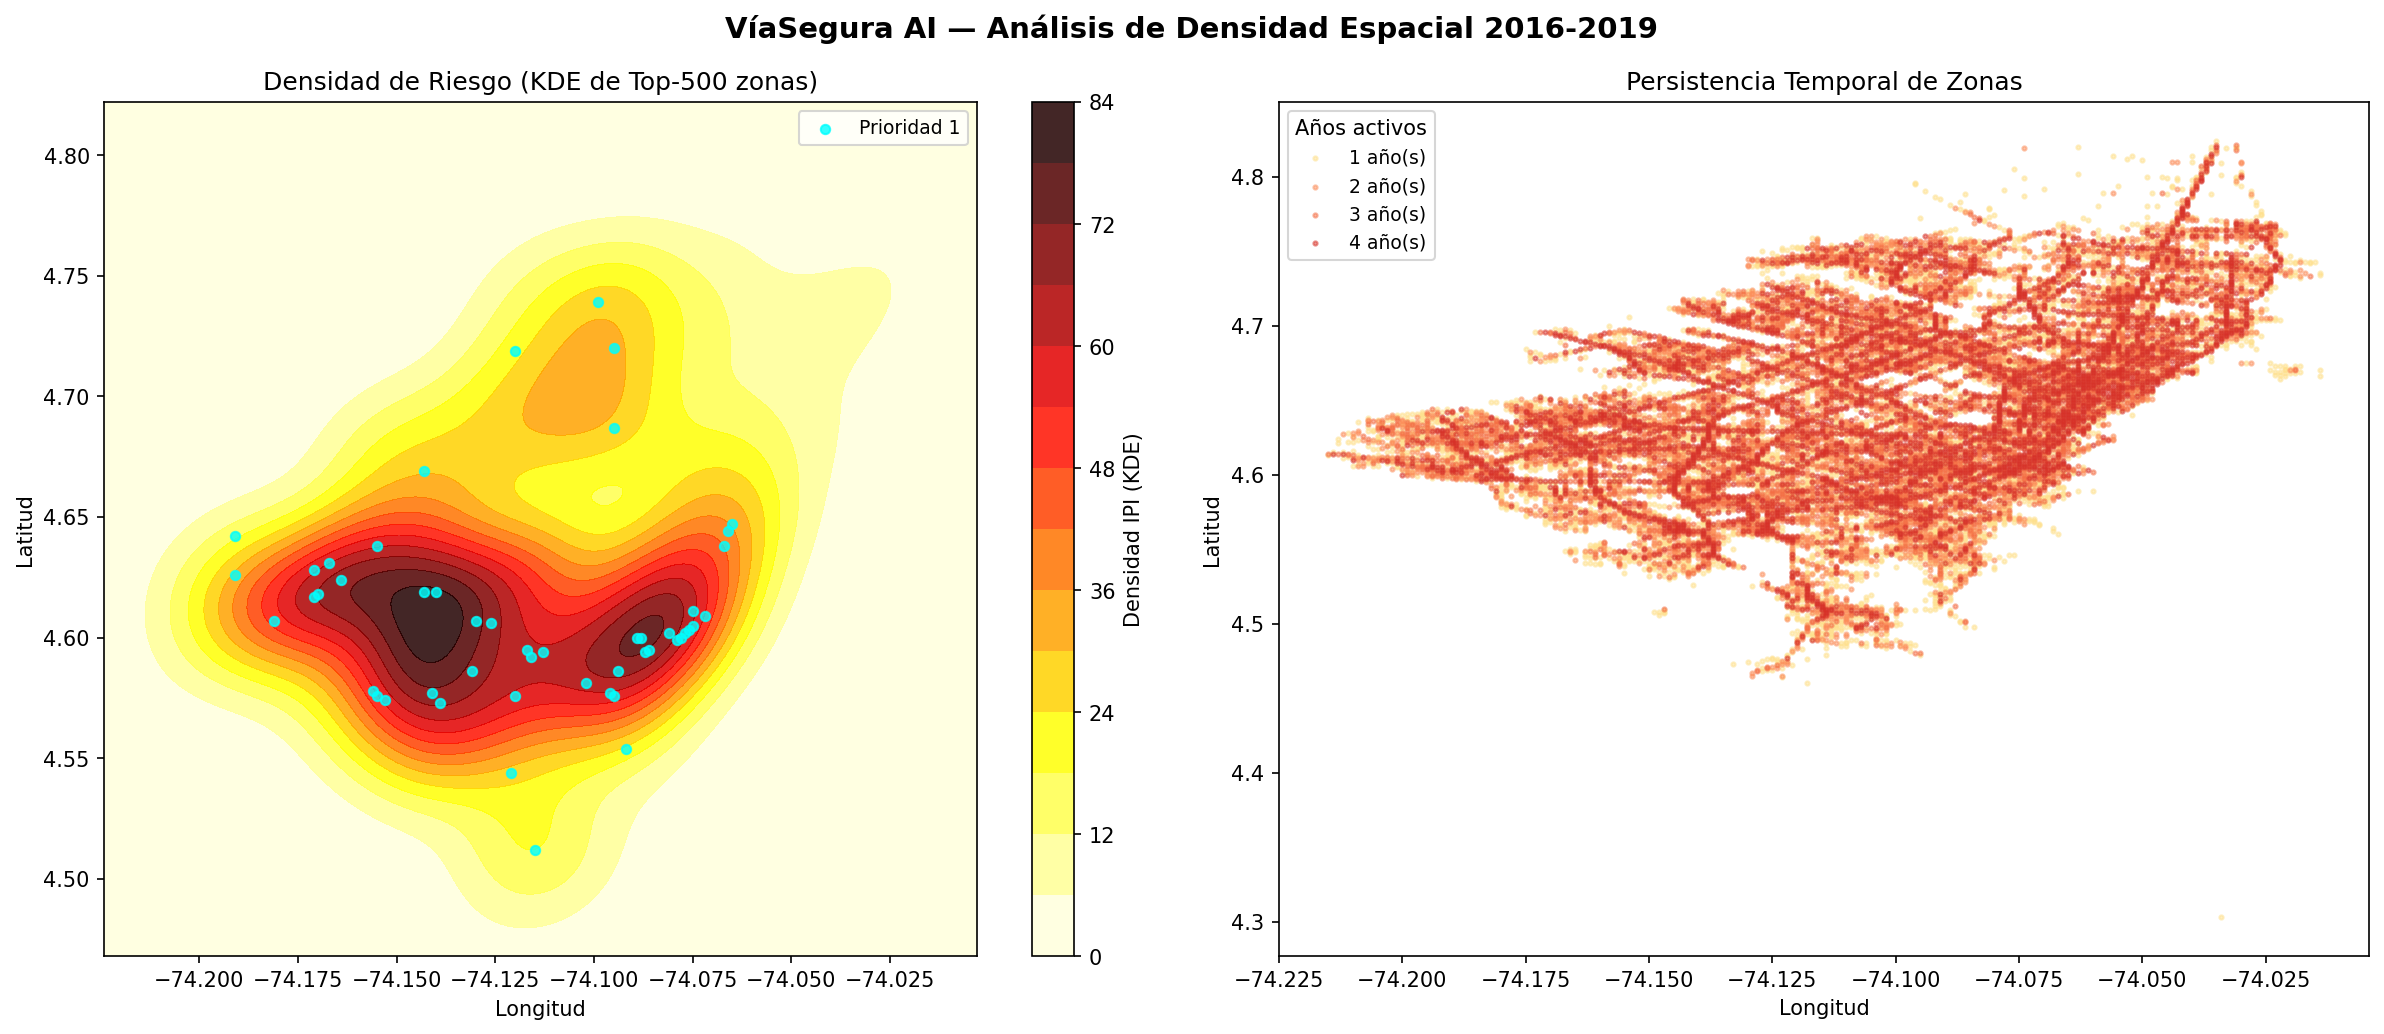

In [18]:
import matplotlib
matplotlib.use("Agg")  # headless rendering
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import gaussian_kde

# ── Proyectar a sistema métrico colombiano para análisis de distancias ──
gdf_zonas_utm = gdf_zonas.to_crs("EPSG:21897")  # Bogotá local
gdf_hex_utm = gdf_hex.to_crs("EPSG:21897")

# ── KDE sobre las 500 zonas con mayor IPI ───────────────────────────────
top500 = gdf_zonas.nlargest(500, "IPI").copy()
xy = np.vstack([top500["LON_ZONA"].values, top500["LAT_ZONA"].values])
kde = gaussian_kde(xy, weights=top500["IPI"].values / 100)

lon_grid = np.linspace(top500["LON_ZONA"].min() - 0.02, top500["LON_ZONA"].max() + 0.02, 200)
lat_grid = np.linspace(top500["LAT_ZONA"].min() - 0.02, top500["LAT_ZONA"].max() + 0.02, 200)
XX, YY = np.meshgrid(lon_grid, lat_grid)
ZZ = kde(np.vstack([XX.ravel(), YY.ravel()])).reshape(XX.shape)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("VíaSegura AI — Análisis de Densidad Espacial 2016-2019", fontsize=14, fontweight="bold")

# Panel A: KDE
ax = axes[0]
cs = ax.contourf(XX, YY, ZZ, levels=15, cmap="hot_r", alpha=0.85)
ax.scatter(p1["LON_ZONA"], p1["LAT_ZONA"], c="cyan", s=20, alpha=0.8, label="Prioridad 1", zorder=5)
fig.colorbar(cs, ax=ax, label="Densidad IPI (KDE)")
ax.set_title("Densidad de Riesgo (KDE de Top-500 zonas)")
ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud")
ax.legend(fontsize=9)

# Panel B: Persistencia (anios_activos)
ax2 = axes[1]
colors_pers = {1: "#fee08b", 2: "#fc8d59", 3: "#f46d43", 4: "#d73027"}
for anios in [1, 2, 3, 4]:
    subset = gdf_zonas[gdf_zonas["anios_activos"] == anios]
    ax2.scatter(subset["LON_ZONA"], subset["LAT_ZONA"],
               c=colors_pers[anios], s=4, alpha=0.5, label=f"{anios} año(s)")
ax2.set_title("Persistencia Temporal de Zonas")
ax2.set_xlabel("Longitud"); ax2.set_ylabel("Latitud")
ax2.legend(title="Años activos", fontsize=9)

plt.tight_layout()
p_density = REPORTS / "densidad_espacial_IPI.png"
plt.savefig(p_density, dpi=150, bbox_inches="tight")
plt.close()
print(f"Figura guardada: {p_density.name}")

# Mostrar en notebook
from IPython.display import Image
Image(filename=str(p_density), width=900)


## 9. Top vías y barrios más críticos

In [19]:
# ── Top 15 vías por criticidad acumulada ─────────────────────────────────
top_vias = (
    df_ipi.groupby("via_predominante")
    .agg(
        n_zonas=("IPI", "count"),
        ipi_max=("IPI", "max"),
        siniestros=("cantidad_siniestros", "sum"),
        muertos=("siniestros_con_muertos", "sum"),
        criticidad=("criticidad_total", "sum"),
    )
    .sort_values("criticidad", ascending=False)
    .head(15)
    .reset_index()
)

print("Top 15 vías más críticas:")
print(top_vias[["via_predominante", "n_zonas", "ipi_max", "siniestros", "muertos", "criticidad"]].to_string())


Top 15 vías más críticas:
                     via_predominante  n_zonas    ipi_max  siniestros  muertos  criticidad
0                             SIN_NMG    11867  94.994162      101606     1439      183590
1                      AVENIDA BOYACA      302  94.124343       16079      299       25767
2              AVENIDA CIUDAD DE CALI      225  94.042615       10192      190       17092
3             AVENIDA CIUDAD DE QUITO      156  93.970811        8267      194       13197
4                     AVENIDA CARACAS      210  95.778167        5976      203       12496
5   AVENIDA PASEO DE LOS LIBERTADORES      212  90.196147        8580      106       11868
6      AVENIDA ALBERTO LLERAS CAMARGO      193  93.146527        7274       54       10790
7                  AVENIDA CENTENARIO      119  92.887916        6613      133        9665
8             AVENIDA PRIMERO DE MAYO      119  94.248687        4415      132        8837
9                    AVENIDA MEDELLIN      106  93.409807       

In [20]:
# ── Top 15 barrios por IPI máximo ────────────────────────────────────────
top_barrios = (
    df_ipi.groupby(["localidad_predominante", "barrio_predominante"])
    .agg(
        n_zonas=("IPI", "count"),
        ipi_max=("IPI", "max"),
        siniestros=("cantidad_siniestros", "sum"),
        muertos=("siniestros_con_muertos", "sum"),
    )
    .sort_values("ipi_max", ascending=False)
    .head(15)
    .reset_index()
)

print("Top 15 barrios por IPI máximo:")
print(top_barrios[["localidad_predominante","barrio_predominante","ipi_max","siniestros","muertos"]].to_string())


Top 15 barrios por IPI máximo:
   localidad_predominante   barrio_predominante    ipi_max  siniestros  muertos
0          CIUDAD BOLIVAR                VERONA  96.275540         462       28
1                SANTA FE         VOTO NACIONAL  95.778167         202       12
2                SANTA FE          LA CAPUCHINA  95.689434         528       10
3                SANTA FE              VERACRUZ  95.084647         998       20
4                    BOSA            EL CORZO I  94.994162          62        4
5           PUENTE ARANDA                 TEJAR  94.965558         342       14
6                SANTA FE              SANTA FE  94.701109         288        6
7      RAFAEL URIBE URIBE           QUIROGA SUR  94.636311         508       12
8                 KENNEDY            CASABLANCA  94.575015         445       14
9                    USME             LA ANDREA  94.455342         598       10
10          SAN CRISTOBAL       VEINTE DE JULIO  94.453590         756       14
11       

Figura guardada: top_vias_barrios_criticos.png


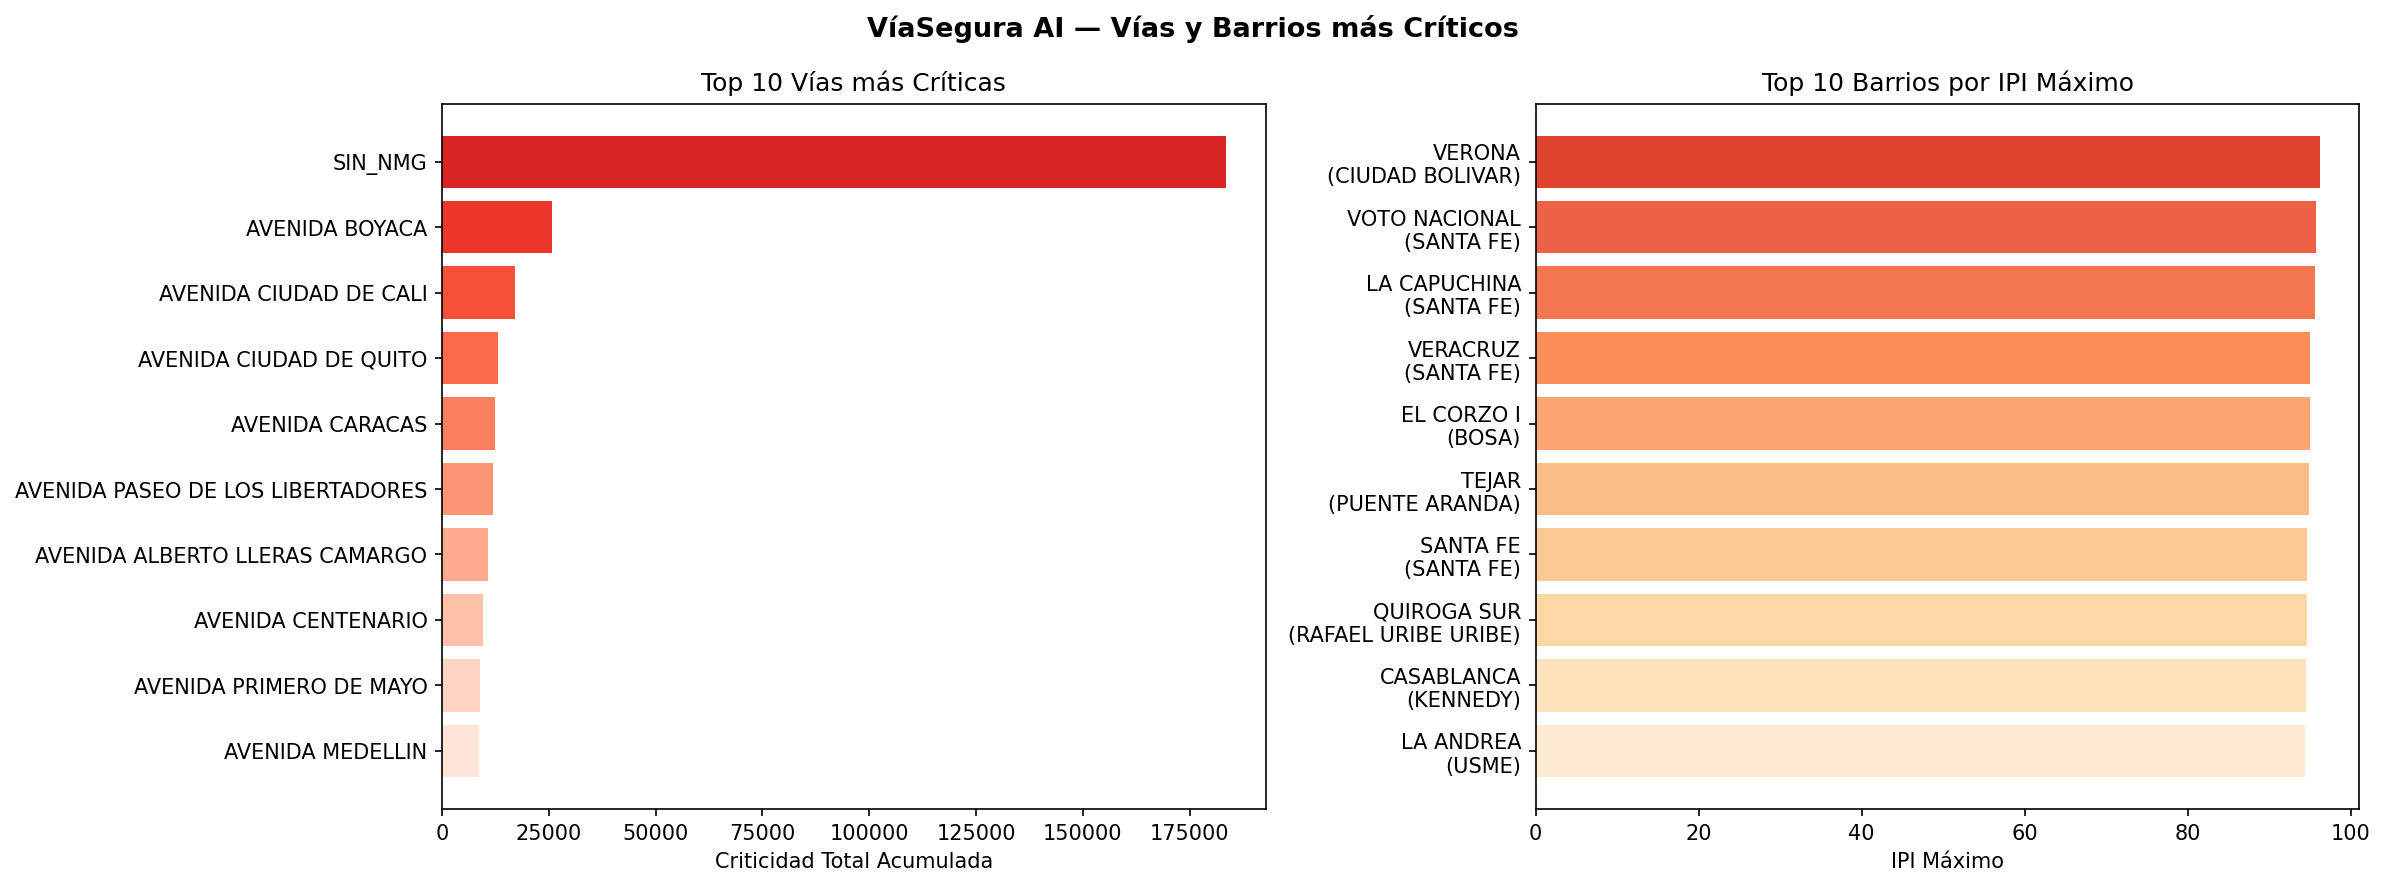

In [21]:
# ── Visualización: doble bar chart ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("VíaSegura AI — Vías y Barrios más Críticos", fontsize=13, fontweight="bold")

# Vías
ax = axes[0]
top_vias_plot = top_vias.head(10)
bars = ax.barh(
    top_vias_plot["via_predominante"],
    top_vias_plot["criticidad"],
    color=plt.cm.Reds_r(np.linspace(0.3, 0.9, len(top_vias_plot))),
)
ax.set_xlabel("Criticidad Total Acumulada")
ax.set_title("Top 10 Vías más Críticas")
ax.invert_yaxis()

# Barrios
ax2 = axes[1]
top_barrios_plot = top_barrios.head(10)
bars2 = ax2.barh(
    top_barrios_plot["barrio_predominante"] + "\n(" + top_barrios_plot["localidad_predominante"] + ")",
    top_barrios_plot["ipi_max"],
    color=plt.cm.OrRd_r(np.linspace(0.3, 0.9, len(top_barrios_plot))),
)
ax2.set_xlabel("IPI Máximo")
ax2.set_title("Top 10 Barrios por IPI Máximo")
ax2.invert_yaxis()

plt.tight_layout()
p_bars = REPORTS / "top_vias_barrios_criticos.png"
plt.savefig(p_bars, dpi=150, bbox_inches="tight")
plt.close()
print(f"Figura guardada: {p_bars.name}")
Image(filename=str(p_bars), width=900)


## 10. Resumen de outputs generados

In [22]:
# ── Guardar top_vias y top_barrios para el dashboard ────────────────────
top_vias.to_csv(REPORTS / "top_vias_criticas_geoespacial.csv", index=False)
top_barrios.to_csv(REPORTS / "top_barrios_criticos_geoespacial.csv", index=False)
ipi_por_loc.to_csv(REPORTS / "ipi_por_localidad_stats.csv", index=False)

# ── Resumen de outputs ───────────────────────────────────────────────────
outputs = [
    MAPS / "ipi_hexagonos_h3.geojson",
    MAPS / "ipi_por_localidad.geojson",
    MAPS / "mapa_choropleth_localidades_IPI.html",
    MAPS / "mapa_hexagonos_H3_IPI.html",
    MAPS / "mapa_heatmap_clusters_P1.html",
    REPORTS / "densidad_espacial_IPI.png",
    REPORTS / "top_vias_barrios_criticos.png",
    REPORTS / "top_vias_criticas_geoespacial.csv",
    REPORTS / "top_barrios_criticos_geoespacial.csv",
    REPORTS / "ipi_por_localidad_stats.csv",
]

print("=" * 60)
print("NB04 COMPLETADO — Outputs generados:")
print("=" * 60)
for p in outputs:
    if p.exists():
        size = p.stat().st_size
        unit = "KB" if size < 1_000_000 else "MB"
        val = size / 1024 if size < 1_000_000 else size / 1_048_576
        print(f"  ✅ {p.name:<45} {val:6.1f} {unit}")
    else:
        print(f"  ❌ {p.name} — NO GENERADO")

print()
print(f"Hexágonos H3 (resolución 8): {len(gdf_hex):,}")
print(f"  Con IPI crítico (≥90):      {(gdf_hex['IPI_hex'] >= 90).sum():,}")
print(f"  Con IPI alto (75-90):       {((gdf_hex['IPI_hex'] >= 75) & (gdf_hex['IPI_hex'] < 90)).sum():,}")
print(f"Localidades analizadas:       {len(gdf_loc_ipi):,}")
print(f"Vías únicas analizadas:       {df_ipi['via_predominante'].nunique():,}")
print(f"Barrios únicos analizados:    {df_ipi['barrio_predominante'].nunique():,}")


NB04 COMPLETADO — Outputs generados:
  ✅ ipi_hexagonos_h3.geojson                       426.0 KB
  ✅ ipi_por_localidad.geojson                        5.8 MB
  ✅ mapa_choropleth_localidades_IPI.html             5.8 MB
  ✅ mapa_hexagonos_H3_IPI.html                     472.4 KB
  ✅ mapa_heatmap_clusters_P1.html                  229.3 KB
  ✅ densidad_espacial_IPI.png                      590.7 KB
  ✅ top_vias_barrios_criticos.png                  121.3 KB
  ✅ top_vias_criticas_geoespacial.csv                0.9 KB
  ✅ top_barrios_criticos_geoespacial.csv             0.8 KB
  ✅ ipi_por_localidad_stats.csv                     22.4 KB

Hexágonos H3 (resolución 8): 581
  Con IPI crítico (≥90):      153
  Con IPI alto (75-90):       270
Localidades analizadas:       274
Vías únicas analizadas:       124
Barrios únicos analizados:    961
